# Pruebas con modelos
---

**Autor:** Jaime Lozano Cillero

# 1. Elegir métrica principal

La clase positiva en esta clasificación es ``is_canceled=1``. Es decir, la reserva se cancela cuando ``is_canceled=1``.

El enunciado indica que el objetivo es predecir cuándo una reserva será cancelada. Lo que no concreta es cuál es la importancia de cada tipo de error para el hotel. Depende del negocio comunicar qué les produce mayor impacto negativo en su actividad. Por lo tanto, suponemos que el coste de ambos errores será comparable.

## Tipos de error

- Falsos positivo (error tipo I): Se predice que la reserva será cancelada pero el cliente se presenta en el hotel.
- Falsos negativos (error tipo II): Se predice que la reserva no será cancelada pero el cliente la cancela, o no se presenta.

## Métrica principal elegida

Elegimos **accuracy** porque mide la proporción de reservas clasificadas correctamente (verdaderos positivos y negativos) respecto al total de predicciones.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

El hándicap sobre "accuracy" es que las clases estén muy desequilibradas. En este dataset se distribuyen en 37% y 63% aproximadamente; presentan ligero desequilibrio que no anula su aplicación.

# 2. Configuración

### Librerías y variables

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf

from typing import List, Optional, Tuple, Union

from matplotlib.colors import ListedColormap

from plotly.subplots import make_subplots
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

from lightgbm import LGBMClassifier

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [2]:
num_jobs = -1
cross_validation_count = 5
acortar_grid_search_cv = True

### Cargar datos

In [ ]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DATASET_PRACTICA_FINAL = f"{PATH_DIRECTORIO_DATOS}/processed/dataset_practica_final_preprocessed.csv"

# Cargamos el dataset de la práctica final
df = pd.read_csv(PATH_DATASET_PRACTICA_FINAL)

# Al cargar los datos desde CSV, Pandas cambia el tipo de datos deseado.
dict_cast_category_cols = {
    'arrival_date_month': 'str',
    'agent' : 'str',
    'company' : 'str',
    'is_repeated_guest': 'str',
}
df = df.astype(dict_cast_category_cols)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119388 entries, 0 to 119387
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119388 non-null  str    
 1   is_canceled                     119388 non-null  int64  
 2   lead_time                       119388 non-null  int64  
 3   arrival_date_year               119388 non-null  int64  
 4   arrival_date_month              119388 non-null  str    
 5   arrival_date_week_number        119388 non-null  int64  
 6   arrival_date_day_of_month       119388 non-null  int64  
 7   stays_in_weekend_nights         119388 non-null  int64  
 8   stays_in_week_nights            119388 non-null  int64  
 9   adults                          119388 non-null  int64  
 10  children                        119388 non-null  int64  
 11  babies                          119388 non-null  int64  
 12  meal                       

In [5]:
# Definir variable objetivo
target_column = 'is_canceled'

# Definimos el índice de la clase cancelado
cancelado_idx = 1

# Diccionario de las categorías de la variable objetivo
dict_target_class_names = {
    0 : 'No cancelado',
    1 : 'Cancelado',
}

# Obtenemos la lista de nombres de las clases
list_target_class_names = dict_target_class_names.values()
list_target_class_names

dict_values(['No cancelado', 'Cancelado'])

## Crear conjuntos de datos train y test

In [6]:
X = df.drop(columns=target_column)
y = df[target_column]

categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include="number").columns


C:\Users\Jaime\AppData\Local\Temp\ipykernel_55924\2306325985.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [7]:
categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'reserved_room_type',
       'deposit_type', 'agent', 'company', 'customer_type'],
      dtype='str')

In [8]:
numerical_columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='str')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(f"Recuento datos X_train: {len(X_train)}")
print(f"Recuento datos X_test:  {len(X_test)}")
print(f"Recuento datos y_train: {len(y_train)}")
print(f"Recuento datos y_test:  {len(y_test)}")

print(f"\nProporción de datos entre test y train:  {len(X_test) / (len(X_train) + len(X_test))}")

Recuento datos X_train: 95510
Recuento datos X_test:  23878
Recuento datos y_train: 95510
Recuento datos y_test:  23878

Proporción de datos entre test y train:  0.20000335042047776


## Distribución de clases en variable target (``is_canceled``)

Verificaremos que el ratio de clases de la variable ``is_canceled`` en el dataset también se mantiene en:
- conjunto de entrenamiento
- conjunto de prueba

In [11]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.630112
1    0.369888
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.627481
1    0.372519
Name: proportion, dtype: float64


## Train-test split estratificado según la variable objetivo

In [12]:
# Se observa que el ratio difiere.
# Hacer train-test split utilizando stratify para que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.629589
1    0.370411
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


# Modelo Regresión Logística (la línea base)
---

In [14]:
# Usar handle_unknown='infrequent_if_exist' para agrupar categorías con pocas apariciones
# Así evitamos errores de entrenamiento cuando aparece alguna categoría poco frecuente en validación
# pero no en entrenamiento.
prep_lr = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_lr = Pipeline([
    ('prep',  prep_lr),
    ('model', LogisticRegression(random_state=42, n_jobs=1)), # Paralelizar sólo en GridSearchCV
])

if acortar_grid_search_cv:
    grid_lr = GridSearchCV(
            pipe_lr,
            param_grid={
                'prep__cat__min_frequency': [20],
                'model__C': [10],
                'model__max_iter': [50],
                'model__solver': ['liblinear'],
            },
            cv=cross_validation_count,
            scoring='accuracy',
            n_jobs=num_jobs,
        )
else:
    grid_lr = GridSearchCV(
        pipe_lr,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__C': [0.1, 1, 10],
            'model__max_iter': [50, 100],
            'model__solver': ['liblinear'],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
grid_lr.fit(X_train, y_train)


c:\Users\Jaime\Documents\Pontia\modulo-05-machine-learning\pontia-ml-proyecto-final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [10], 'model__max_iter': [50], 'model__solver': ['liblinear'], 'prep__cat__min_frequency': [20]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [15]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_lr.best_params_}")
print(f"Mejor score obtenido: {grid_lr.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'model__C': 10, 'model__max_iter': 50, 'model__solver': 'liblinear', 'prep__cat__min_frequency': 20}
Mejor score obtenido: 82.70%


**Log de mejores hiperparámetros encontrados para LogisticRegression**

{'model__C': 10, 'model__max_iter': 50, 'model__solver': 'liblinear', 'prep__cat__min_frequency': 20}
Mejor score obtenido: 83.01%


In [16]:
modelo_lr = clone(grid_lr.best_estimator_)
modelo_lr.fit(X_train, y_train)

c:\Users\Jaime\Documents\Pontia\modulo-05-machine-learning\pontia-ml-proyecto-final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [17]:
# Predecir sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lr.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Accuracy:  82.32%
Precisión: 80.15%
Recall:    0.69
F1-Score:  0.74
AUC:       0.91


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     15033
           1       0.80      0.69      0.74      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.80      0.80     23878
weighted avg       0.82      0.82      0.82     23878



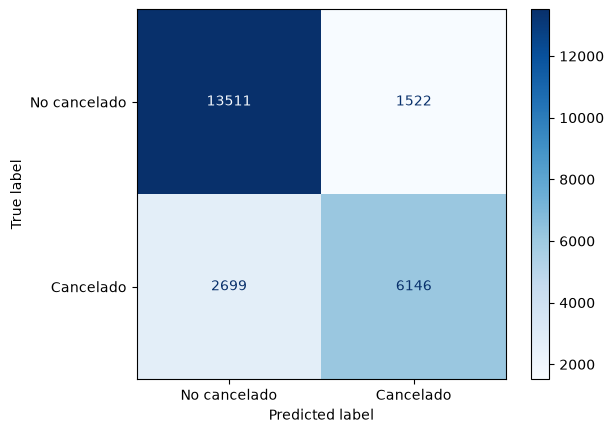

In [18]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

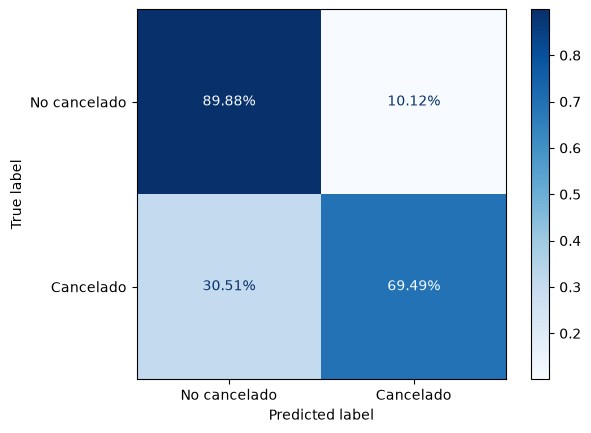

In [19]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

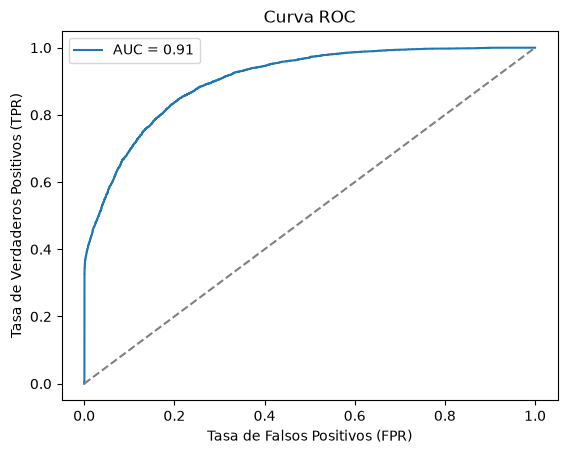

In [20]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo Árbol de Decisión
---

In [21]:
%%time

prep_dt = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_dt = Pipeline([
    ('prep',  prep_dt),
    ('model', DecisionTreeClassifier(random_state=42)),
])

if acortar_grid_search_cv:
    grid_dt = GridSearchCV(
        pipe_dt,
        param_grid={
            'prep__cat__min_frequency': [10],
            'model__max_depth': [20],
            'model__min_samples_split': [5],
            'model__min_samples_leaf': [1],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_dt = GridSearchCV(
        pipe_dt,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
    
grid_dt.fit(X_train, y_train)

CPU times: total: 9.84 s
Wall time: 30.2 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [20], 'model__min_samples_leaf': [1], 'model__min_samples_split': [5], 'prep__cat__min_frequency': [10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [22]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_dt.best_params_}")
print(f"Mejor score obtenido: {grid_dt.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 86.31%


**Log de mejores hiperparámetros encontrados para DecisionTreeClassifier**

{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 86.32%


In [23]:
modelo_dt = clone(grid_dt.best_estimator_)
modelo_dt.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Accuracy:  0.87
Precisión: 0.83
Recall:    0.80
F1-Score:  0.82
AUC:       0.90


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     15033
           1       0.83      0.80      0.82      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



In [24]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy:  0.87
Precisión: 0.83
Recall:    0.80
F1-Score:  0.82
AUC:       0.90


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     15033
           1       0.83      0.80      0.82      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



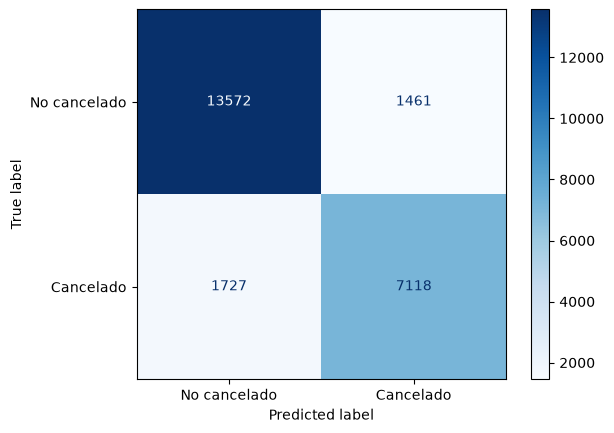

In [25]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

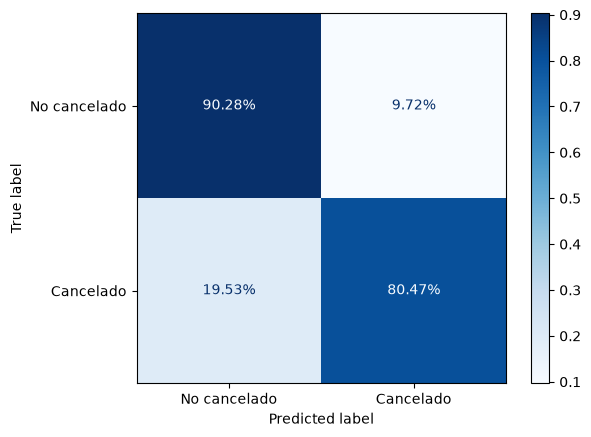

In [26]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

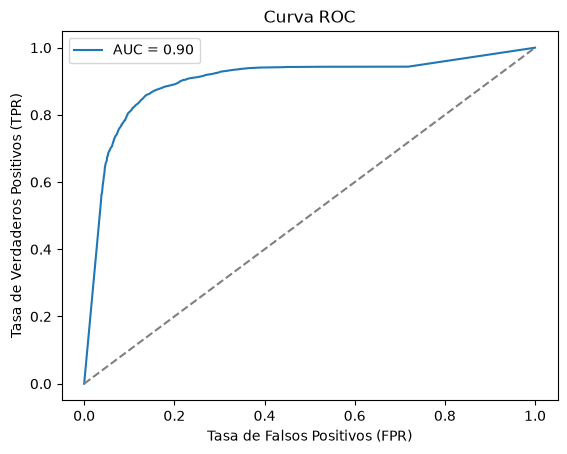

In [27]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo Random Forest
---

In [28]:
%%time

prep_rfc = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_rfc = Pipeline([
    ('prep',  prep_rfc),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1)), # Paralelizar sólo en GridSearchCV
])

if acortar_grid_search_cv:
    grid_rfc = GridSearchCV(
        pipe_rfc,
        param_grid={
            'prep__cat__min_frequency': [20],
            'model__n_estimators': [200],
            'model__max_depth': [None],
            'model__min_samples_split': [2],
            'model__min_samples_leaf': [1],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_rfc = GridSearchCV(
        pipe_rfc,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )

grid_rfc.fit(X_train, y_train)

CPU times: total: 1min 8s
Wall time: 3min 3s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None], 'model__min_samples_leaf': [1], 'model__min_samples_split': [2], 'model__n_estimators': [200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [29]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_rfc.best_params_}")
print(f"Mejor score obtenido: {grid_rfc.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'prep__cat__min_frequency': 20}
Mejor score obtenido: 88.91%


**Log de mejores hiperparámetros encontrados para RandomForestClassifier**

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'prep__cat__min_frequency': 20}
Mejor score obtenido: 89.04%


In [30]:
modelo_rfc = clone(grid_rfc.best_estimator_)
modelo_rfc.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_rfc.predict_proba(X_test)[:, cancelado_idx]

In [31]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy:  0.89
Precisión: 0.89
Recall:    0.82
F1-Score:  0.85
AUC:       0.96


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     15033
           1       0.89      0.82      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.88      0.88     23878
weighted avg       0.89      0.89      0.89     23878



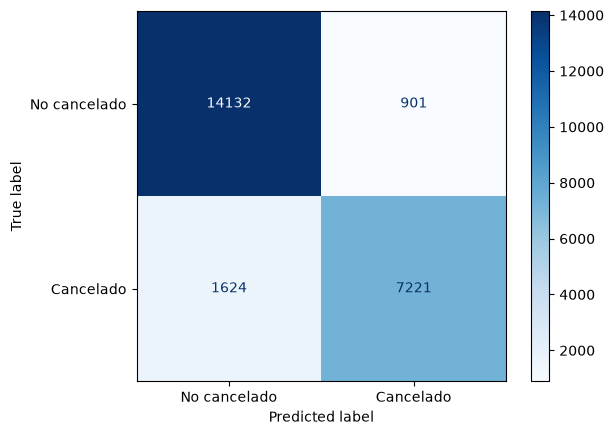

In [32]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

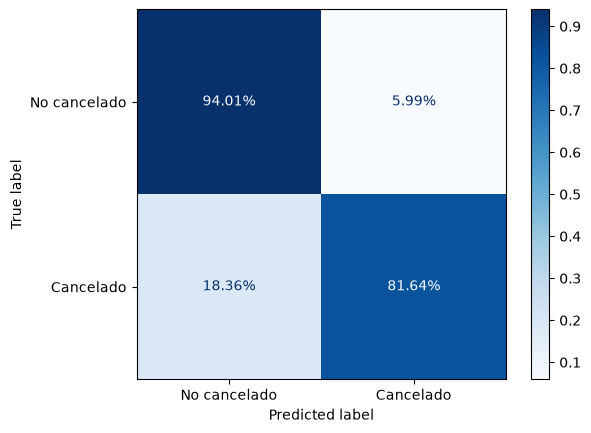

In [33]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

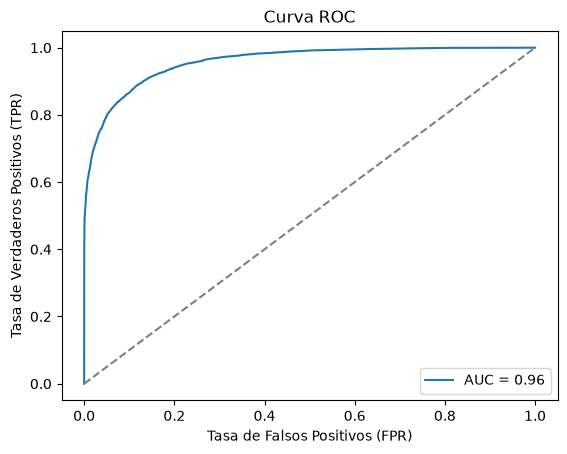

In [34]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

#### Gráfico de importancia de variables

In [35]:
# Importancia de variables
col_importancia_rfc = modelo_rfc.named_steps['model'].feature_importances_
col_nombres = modelo_rfc.named_steps['prep'].get_feature_names_out()

df_importances_rfc = pd.DataFrame({
    'variable' : col_nombres,
    'importancia' : col_importancia_rfc
}).sort_values('importancia', ascending=False).reset_index(drop=True)

In [36]:
df_importances_rfc.head(20)

,variable,importancia
0,num__lead_time,0.104835
1,num__adr,0.067762
2,cat__deposit_type_Non Refund,0.067111
3,cat__deposit_type_No Deposit,0.066775
4,cat__country_PRT,0.061123
5,num__total_of_special_requests,0.053469
6,num__arrival_date_day_of_month,0.050787
7,num__arrival_date_week_number,0.044310
8,num__stays_in_week_nights,0.036239
9,num__previous_cancellations,0.026821


Llama la atención que pesen tanto valores concretos de ciertas categóricas:
- ``cat__country_PRT`` es el país Portugal.

In [37]:
# Al hacer one-hot encoding, cada valor de las columnas categóricas pasa a ocupar su propia columna.
# Agregar las importancias por el nombre de la variable original.

def variable_original(nombre):
    bloque, resto = nombre.split('__', 1)
    if bloque == 'num':
        return resto
    # 'cat': la columna categórica más larga que sea prefijo del nombre de la dummy
    candidatas = [col for col in categorical_columns if resto.startswith(col + '_')]
    return max(candidatas, key=len) if candidatas else resto

df_importances_rfc['variable_original'] = df_importances_rfc['variable'].apply(variable_original)

df_importances_rfc_agr = (
    df_importances_rfc
    .groupby('variable_original', as_index=False)['importancia']
    .sum()
    .sort_values('importancia', ascending=False)
    .reset_index(drop=True)
)

df_importances_rfc_agr

,variable_original,importancia
0,deposit_type,0.134182
1,country,0.130639
2,lead_time,0.104835
3,agent,0.072652
4,adr,0.067762
5,total_of_special_requests,0.053469
6,arrival_date_day_of_month,0.050787
7,arrival_date_month,0.046204
8,arrival_date_week_number,0.044310
9,market_segment,0.038544


In [38]:
# Comprobar que la suma de todas las importancias es 1.
df_importances_rfc_agr['importancia'].sum()

np.float64(0.9999999999999999)

C:\Users\Jaime\AppData\Local\Temp\ipykernel_55924\2327113226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='variable_original', data=df_importances_rfc_agr.head(15), palette='viridis')


Text(0, 0.5, 'Variable')

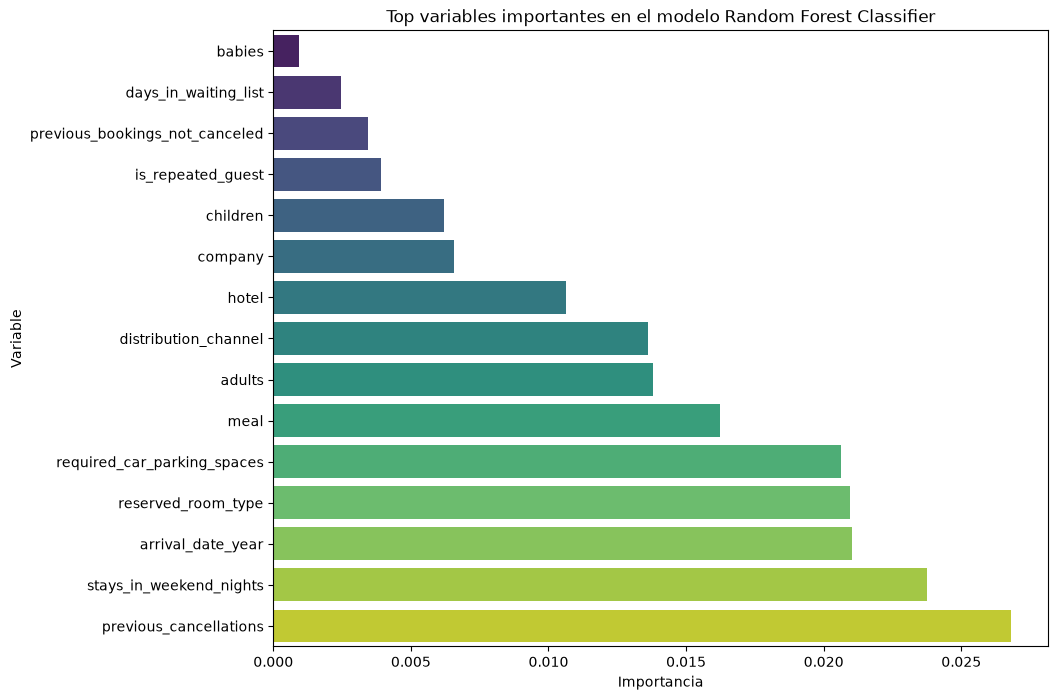

In [45]:
# Ordenamos el dataframe por la importancia de manera ascendente
df_importances_rfc_agr = df_importances_rfc_agr.sort_values(by='importancia', ascending=True)

# Visualización de la importancia de las variables
plt.figure(figsize=(10, 8))
sns.barplot(x='importancia', y='variable_original', data=df_importances_rfc_agr.head(15), palette='viridis')
plt.title('Top variables importantes en el modelo Random Forest Classifier')
plt.xlabel('Importancia')
plt.ylabel('Variable')

# Modelo Gradient Boosting - LightGBM
---

In [46]:
prep_lgbm = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
]).set_output(transform='pandas') # Para que a LightGBM le lleguen los nombre de las columnas

pipe_lgbm = Pipeline([
    ('prep',  prep_lgbm),
    ('model', LGBMClassifier(
        random_state=42,
        max_depth=-1, # No limitar la profundidad porque está relacionada con el número de hojas posibles
        n_jobs=1, # Paralelizar sólo en GridSearchCV
    )), 
])

if acortar_grid_search_cv:
    grid_lgbm = GridSearchCV(
        pipe_lgbm,
        param_grid={
            'prep__cat__min_frequency': [10],
            'model__n_estimators': [500],
            'model__num_leaves': [127],
            'model__learning_rate': [0.1],
            'model__min_child_samples': [20],
            'model__subsample': [0.8],
            'model__subsample_freq': [1],
            'model__colsample_bytree': [1.0],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_lgbm = GridSearchCV(
        pipe_lgbm,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__n_estimators': [200, 500],
            'model__num_leaves': [31, 63, 127],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_samples': [20, 50],
            'model__subsample': [0.8, 1.0],
            'model__subsample_freq': [1],
            'model__colsample_bytree': [0.8, 1.0],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )

grid_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35378, number of negative: 60132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1522
[LightGBM] [Info] Number of data points in the train set: 95510, number of used features: 362
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370411 -> initscore=-0.530452
[LightGBM] [Info] Start training from score -0.530452


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [1.0], 'model__learning_rate': [0.1], 'model__min_child_samples': [20], 'model__n_estimators': [500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

In [47]:
# Visualizar los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_lgbm.best_params_}")
print(f"Mejor score obtenido: {grid_lgbm.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__min_child_samples': 20, 'model__n_estimators': 500, 'model__num_leaves': 127, 'model__subsample': 0.8, 'model__subsample_freq': 1, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 88.90%


**Log de mejores hiperparámetros encontrados para Gradient Boosting LGBMClassifier**

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__min_child_samples': 20, 'model__n_estimators': 500, 'model__num_leaves': 127, 'model__subsample': 0.8, 'model__subsample_freq': 1, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 88.90%


In [48]:
modelo_lgbm = clone(grid_lgbm.best_estimator_)
modelo_lgbm.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lgbm.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lgbm.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35378, number of negative: 60132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1522
[LightGBM] [Info] Number of data points in the train set: 95510, number of used features: 362
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370411 -> initscore=-0.530452
[LightGBM] [Info] Start training from score -0.530452
Accuracy:  0.89
Precisión: 0.87
Recall:    0.84
F1-Score:  0.85
AUC:       0.96


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     15033
           1       0.87      0.84      0.85      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.88  

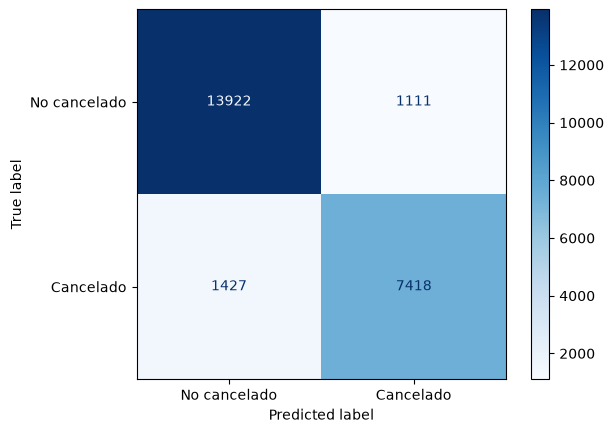

In [49]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

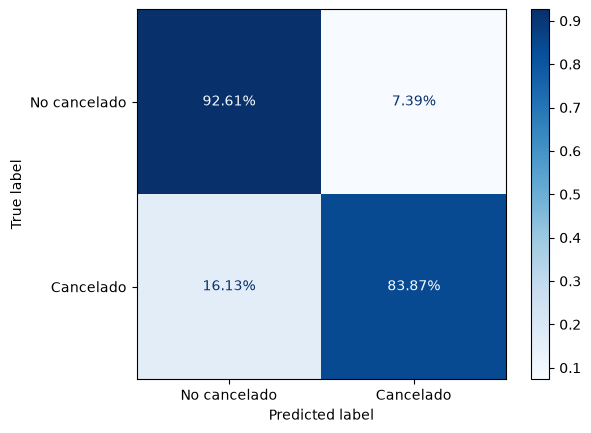

In [50]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

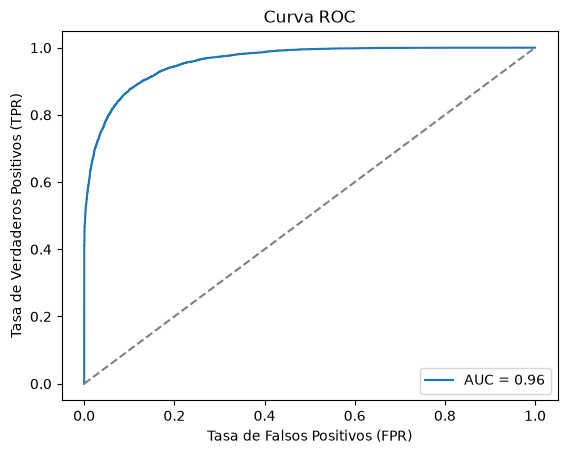

In [51]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Red neuronal multicapa usando Keras de TensorFlow
---

In [52]:
prep_keras = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(
        sparse_output=False,
        handle_unknown='infrequent_if_exist',
        min_frequency=20, # Mantener el valor más frecuente al entrenar el resto de algoritmos
    ), categorical_columns),
])

# Aplicar la transformación a las columnas categóricas y numéricas
X_train_transformed = prep_keras.fit_transform(X_train)
X_test_transformed = prep_keras.transform(X_test)

# Definir la arquitectura del modelo
modelo_keras = models.Sequential([
    layers.Input(shape=(X_train_transformed.shape[1], ), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilar el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo_keras.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
modelo_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 128)            │        46,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,217 (223.50 KB)

 Trainable params: 57,217 (223.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time

# Entrenamos el modelo y guardamos el historial para visualizar el aprendizaje
history_keras = modelo_keras.fit(
    X_train_transformed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.8296 - loss: 0.3576 - val_accuracy: 0.8402 - val_loss: 0.3353
Epoch 2/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8410 - loss: 0.3322 - val_accuracy: 0.8556 - val_loss: 0.3095
Epoch 3/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8500 - loss: 0.3200 - val_accuracy: 0.8548 - val_loss: 0.3081
Epoch 4/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8496 - loss: 0.3220 - val_accuracy: 0.8561 - val_loss: 0.3057
Epoch 5/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8525 - loss: 0.3175 - val_accuracy: 0.8580 - val_loss: 0.3113
Epoch 6/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8522 - loss: 0.3131 - val_accuracy: 0.8578 - val_loss: 0.3033
Epoch 7/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8543 - loss: 0.3082 - val_accuracy: 0.8595 - val_loss: 0.3048
Epoch 8/50
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8555 - loss: 0.30

In [ ]:
# Evaluamos el modelo en el conjunto de prueba
loss_keras, accuracy_keras = modelo_keras.evaluate(X_test_transformed, y_test)
print(f"Test Loss: {loss_keras:.4f}, Test Accuracy: {accuracy_keras:.4f}")

In [ ]:
# Mostrar la función de coste del modelo
plt.plot(history_keras.history['loss'], label='Acc train')
plt.plot(history_keras.history['val_loss'], label='Acc val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

### EarlyStopping para Keras

In [ ]:
# Definimos un callback de EarlyStopping para detener el entrenamiento si no hay mejora en la validación
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida de validación
    patience=10,         # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True  # Restaura los mejores pesos del modelo
)

In [ ]:
%%time
# Entrenar el modelo y guardar el historial para visualizar el aprendizaje
history_early = modelo_keras.fit(X_train_transformed, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[early_stopping])

# Entrenar el modelo con EarlyStopping y guardar el historial para visualizar el aprendizaje
history_keras = modelo_keras.fit(
    X_train_transformed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8138 - loss: 0.3862 - val_accuracy: 0.8453 - val_loss: 0.3210
Epoch 2/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8467 - loss: 0.3293 - val_accuracy: 0.8560 - val_loss: 0.3091
Epoch 3/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8506 - loss: 0.3181 - val_accuracy: 0.8576 - val_loss: 0.3158
Epoch 4/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8508 - loss: 0.3148 - val_accuracy: 0.8573 - val_loss: 0.3044
Epoch 5/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8542 - loss: 0.3145 - val_accuracy: 0.8604 - val_loss: 0.2997
Epoch 6/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8543 - loss: 0.3096 - val_accuracy: 0.8561 - val_loss: 0.3026
Epoch 7/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8518 - loss: 0.3119 - val_accuracy: 0.8602 - val_loss: 0.2976
Epoch 8/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8571 - loss: 0

In [ ]:
# Evaluamos el modelo en el conjunto de prueba
loss_keras, accuracy_keras = modelo_keras.evaluate(X_test_transformed, y_test)
print(f"Test Loss: {loss_keras:.4f}, Test Accuracy: {accuracy_keras:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8634 - loss: 0.2924
Test Loss: 0.2919, Test Accuracy: 0.8626


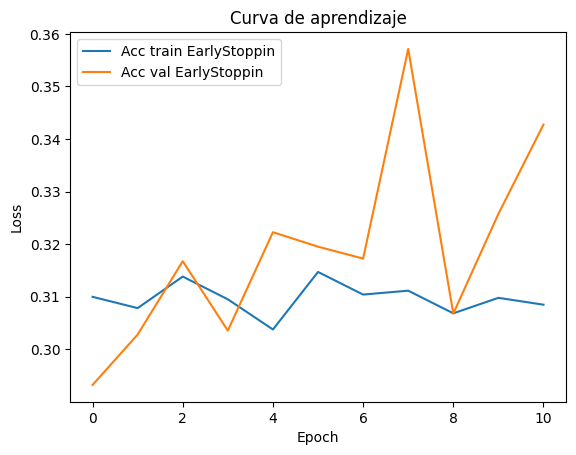

In [ ]:
# Mostrar la función de coste del modelo con EarlyStopping
plt.plot(history_keras.history['loss'], label='Acc train EarlyStoppin')
plt.plot(history_keras.history['val_loss'], label='Acc val EarlyStoppin')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

---

In [ ]:
# Hacer predicciones y convertir probabilidades a 0/1
y_pred_prob = modelo_keras.predict(X_test_transformed)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 999us/step


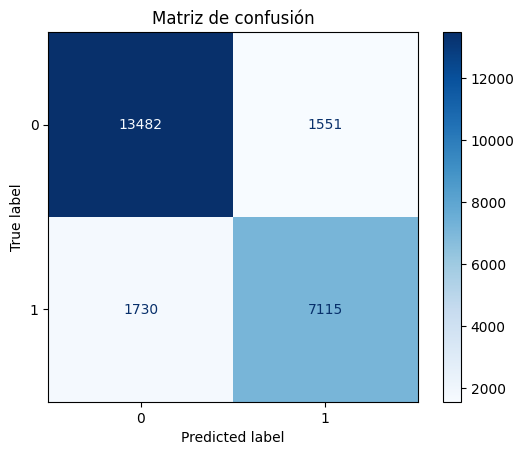

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

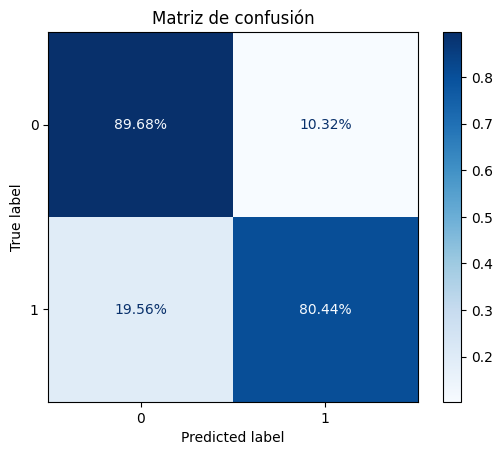

In [ ]:
# Matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.show()

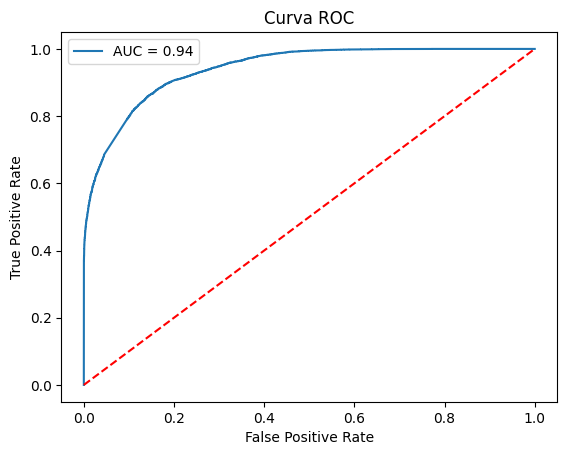

In [ ]:
# Obtenemos la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [ ]:
print(f"ROC-AUC: {roc_auc:.5f}")

ROC-AUC: 0.94124


In [ ]:
print("Evaluando 'accuracy' en Keras con EarlyStopping:", modelo_keras.evaluate(X_test_transformed, y_test, verbose=0)[1])

Evaluando 'accuracy' con EarlyStopping: 0.8625931739807129
